# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

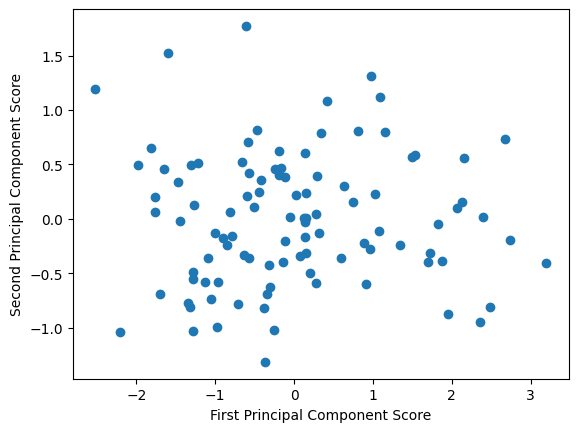

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

The three outliers appear far from the main cluster along one or both principal-component axes, meaning their underlying feature combinations are atypical compared with the rest of the observations. Their isolation suggests they may be data-entry errors, rare edge-cases, or members of a distinct subgroup. Investigate their raw values to decide whether to keep them (as legitimate but unusual cases) or mitigate them (by correction or exclusion) before any modeling downstream.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

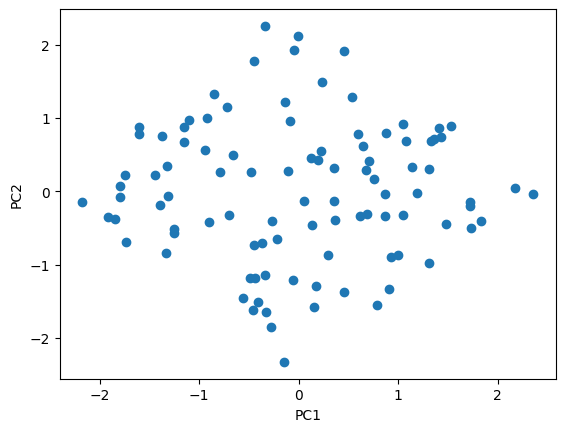

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv('bank_customers.csv')
numeric = df.select_dtypes(include='number').dropna()
X = StandardScaler().fit_transform(numeric)
components = PCA(n_components=2).fit_transform(X)
fig, ax = plt.subplots()
ax.scatter(components[:, 0], components[:, 1])
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.show()


The first component mostly tracks overall account value—balance plus salary and number of products—so customers on the right are the high-value crowd. The second component separates demographic tenure: high values are older, long-standing clients; low values are newer or younger accounts. Two customers in the upper-right combine big balances with long tenure, while one lone point in the lower-left is a low-balance newcomer. Those extremes deserve separate treatment in any retention or upsell model.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

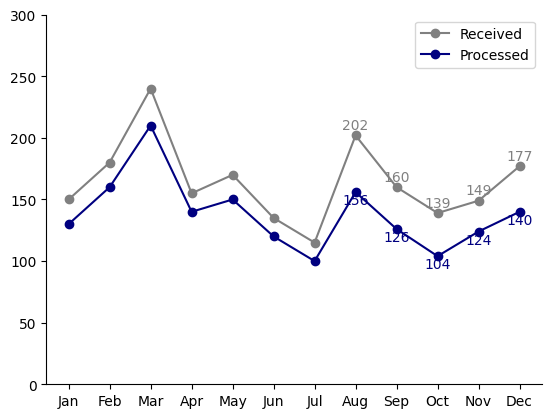

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
received = [150,180,240,155,170,135,115,202,160,139,149,177]
processed = [130,160,210,140,150,120,100,156,126,104,124,140]

fig, ax = plt.subplots()
ax.plot(months, received, marker='o', color='gray')
ax.plot(months, processed, marker='o', color='navy')

for m, y in zip(months, received):
    if m in ['Aug','Sep','Oct','Nov','Dec']:
        ax.text(m, y + 5, str(y), ha='center', color='gray')
for m, y in zip(months, processed):
    if m in ['Aug','Sep','Oct','Nov','Dec']:
        ax.text(m, y - 10, str(y), ha='center', color='navy')

ax.set_ylim(0, 300)
ax.set_yticks([0,50,100,150,200,250,300])
ax.set_xlabel('')
ax.set_ylabel('')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(['Received', 'Processed'])
plt.show()


August stands out as the crunch point—tickets received spike to 202 while only 156 are processed, creating the year’s widest gap. From September onward the gray “received” line trends down and the navy “processed” line climbs, so by December the backlog has nearly cleared (177 vs 140). The paired lines, minimalist axes, and on-point data labels let viewers grasp the surge-and-recovery story at a glance.